<a href="https://colab.research.google.com/github/KULDEEPSONI-source/MACHINE-LEARNING/blob/main/ENSEMBLE-BAGGING-VS-RANDOOMFOREST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Overview of Libraries

Here is a brief breakdown of the libraries you imported and how they function within your data science workflow:

* **NumPy (`import numpy as np`)**: The fundamental package for scientific computing in Python. It provides support for large, multi-dimensional arrays and matrices, along with a collection of mathematical functions to operate on these arrays efficiently.
* **Pandas (`import pandas as pd`)**: Built on top of NumPy, this library provides high-performance data structures like **DataFrames**. It is the standard tool for data manipulation, cleaning, analysis, and alignment.
* **Matplotlib (`import matplotlib.pyplot as plt`)**: A comprehensive library for creating static, animated, and interactive visualizations in Python. You will likely use this to plot the decision boundaries or the structure of the trees in your ensemble models.
* **Scikit-Learn (`sklearn`)**: The primary machine learning library for Python.
* **`datasets`**: Provides tools to generate synthetic datasets (like `make_classification`) or load popular real-world datasets for testing.
* **`ensemble`**: Contains advanced algorithms that combine multiple learning models (like Bagging and Random Forests) to improve overall predictive performance and stability.
* **`tree`**: Includes modules for decision tree-based algorithms and the `plot_tree` utility, which allows you to visualize the logic inside your trained trees.



---


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import plot_tree

With that code, you have generated a synthetic dataset specifically designed for testing classification algorithms. Here is a breakdown of what those parameters are doing:

### Data Configuration Details

| Parameter | Value | Description |
| --- | --- | --- |
| `n_samples` | **200** | The total number of data points to generate. |
| `n_features` | **5** | The total number of input features (columns) in your dataset. |
| `n_redundant` | **0** | Ensures none of the features are linear combinations of others (making the task cleaner). |
| `n_informative` | **5** | All 5 features are "useful" for predicting the target variable, making the data highly relevant. |
| `n_clusters_per_class` | **1** | Each of the two classes forms a single, cohesive "blob," making it relatively straightforward for models to classify. |

---


In [ ]:
X, y = make_classification(n_samples=200,n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)


In [ ]:
df = pd.DataFrame(X, columns=['col1', 'col2', 'col3', 'col4', 'col5'])
df['target'] = y

In [ ]:
len(df)

200

In [ ]:
df.shape

(200, 6)

----
By setting `max_features=2` in your `BaggingClassifier`, you are introducing a specific type of **feature bagging**.

### What happens when you set `max_features=2`?

In standard bagging, the model creates different versions of the training set by sampling **rows** (observations). When you add `max_features=2`, the model **also** restricts each individual base estimator (the trees) to only look at **2 out of the 5 available features** for every bootstrap sample it creates.

* **Increased Diversity:** Because each tree only sees a small subset of the total information, the trees become highly decorrelated.
* **Reduced Overfitting:** By forcing trees to make decisions based on limited information, you prevent the model from becoming too reliant on a single, dominant feature.
* **Comparison to Random Forest:** This setting effectively makes your `BaggingClassifier` behave very similarly to a `RandomForestClassifier`. In fact, a `RandomForestClassifier` is essentially a `BaggingClassifier` that uses Decision Trees as the base estimator and automatically performs this feature selection at every split.

---





In [ ]:
bag = BaggingClassifier(max_features=2)

In [ ]:
bag.fit(df.iloc[:,:5],df.iloc[:,-1])

BaggingClassifier(max_features=2)

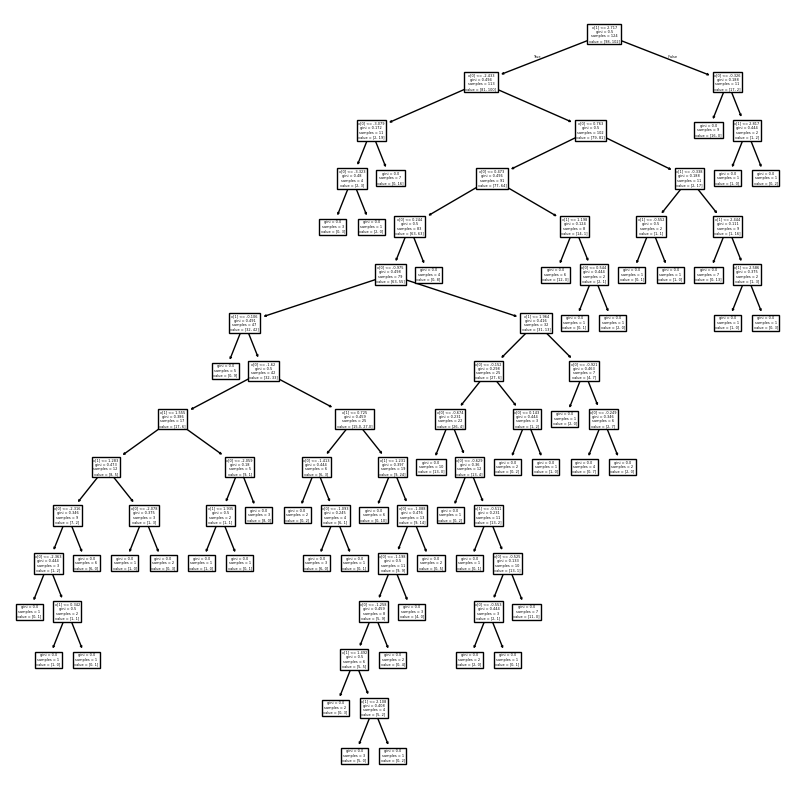

In [ ]:
plt.figure(figsize=(10,10))
plot_tree(bag.estimators_[0])
plt.show()

In [ ]:
rf = RandomForestClassifier(max_features=2)


In [ ]:
rf.fit(df.iloc[:,:5],df.iloc[:,-1])


RandomForestClassifier(max_features=2)

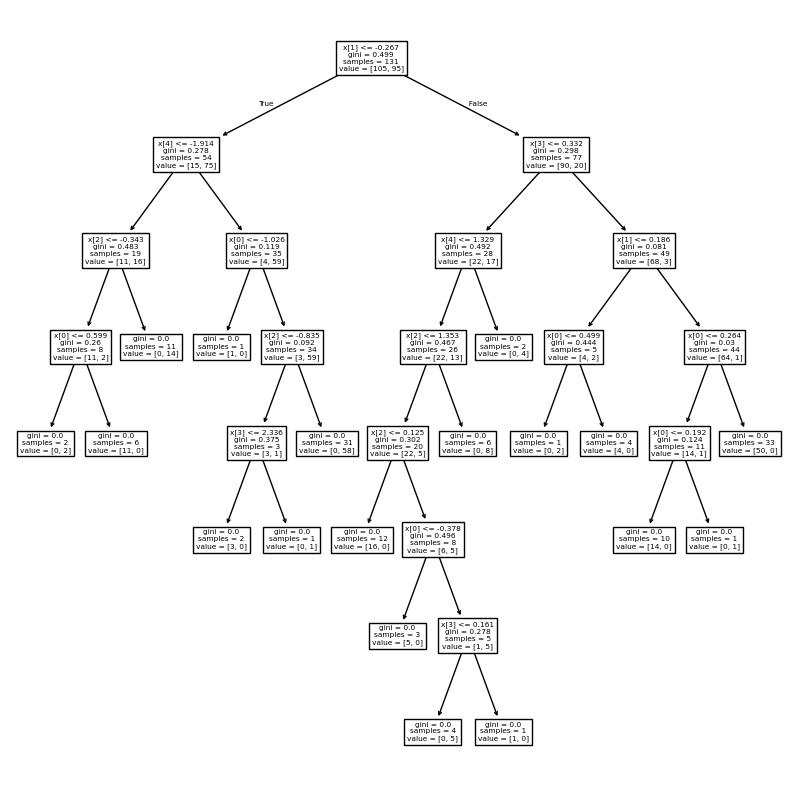

In [ ]:
plt.figure(figsize=(10,10))
plot_tree(rf.estimators_[0])
plt.show()

The fundamental difference is that **Random Forest is a specialized, optimized version of Bagging** specifically designed for decision trees.

Here is the breakdown of the major differences:

### 1. Feature Selection (The "Secret Sauce")

* **Bagging:** By default, each base model (tree) in a `BaggingClassifier` looks at **all** available features when searching for the best split at a node.
* **Random Forest:** At **every single node** within each tree, the algorithm randomly selects a **subset** of features and only considers those for the best split. This "feature bagging" (or random subspace method) forces the trees to be much more diverse and less correlated with each other.

### 2. Flexibility vs. Specialization

* **Bagging:** It is a generic meta-algorithm. You can use **any** machine learning model as the "base estimator." For example, you can use `BaggingClassifier(LogisticRegression())` or `BaggingClassifier(SVC())`.
* **Random Forest:** It is hard-coded to work with **Decision Trees**. Because it is specialized for trees, it includes optimizations that a generic Bagging classifier might not have (like internal logic for feature importance and out-of-bag error calculation).

### 3. Diversity and Variance

* **Bagging:** Diversity between trees comes *only* from the random row samples (bootstrapping).
* **Random Forest:** Diversity comes from *both* the row samples and the random feature selection at every split. This dual-layer of randomness typically leads to lower correlation between trees, which often results in better performance and stronger resistance to overfitting.

### Summary Table

| Feature | Bagging Classifier | Random Forest Classifier |
| --- | --- | --- |
| **Base Estimator** | Flexible (can be anything) | Only Decision Trees |
| **Feature Selection** | Uses all features by default | Random subset of features at every node |
| **Primary Goal** | Reduce variance via bootstrapping | Reduce variance via bootstrapping + feature randomness |
| **Randomness** | Data/Row sampling only | Data sampling + Feature sampling |

**In short:** If you use a `BaggingClassifier` and set `max_features` to be less than your total feature count, you are essentially building a custom Random Forest. The `RandomForestClassifier` is just an optimized, pre-configured package for exactly that workflow.